# Module 05, 06 & 07 Assignment
## Understanding the ML Problem, Exploratory Data Analysis (EDA) and Basic Preprocessing
**Dataset:** Titanic – Machine Learning from Disaster (Kaggle)

Download the **train.csv** file from Kaggle’s Titanic competition and upload it to this notebook. Rename it to `titanic.csv` or update the file name in the loading cell.
Dataset link: https://www.kaggle.com/datasets/yasserh/titanic-dataset

Total Marks: **100**

### Instructions
- This assignment covers:
  - **Module 05:** Basic ML problem framing (features, target, task type).
  - **Module 06:** Exploratory Data Analysis (EDA).
  - **Module 07:** Basic Preprocessing (handling missing values, encoding, scaling).
- Answer all questions inside this notebook using code and markdown.
- Do not delete the original question texts.
- At the end, the notebook should run from top to bottom without errors.

In [52]:
# ==============================
# Setup
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Libraries imported.")

Libraries imported.


---
## Part 0: Understanding the ML Problem (Module 05) – 10 marks

### 0.1 Load the Dataset and Inspect (5 marks)
**Tasks:**
1. Load `titanic.csv` into a pandas DataFrame.
2. Show `.head()`, `.info()`, and `.describe()`.
3. Briefly look at the column names and data types.


In [29]:
# 0.1 Load the Dataset and Inspect
# TODO: Change file name if needed.

df = pd.read_csv("titanic.csv")#Download the .csv file from Kaggle

print("Shape of dataset:", df.shape)
display(df.head())

print("\nInfo:")
print(df.info())

print("\nDescribe (numeric columns):")
display(df.describe())

Shape of dataset: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Describe (numeric columns):


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### 0.2 Identify Features, Target and Task Type (5 marks)
**Tasks:**
Based on the dataset:
1. Identify the **target variable** for a predictive model.
2. List at least **5 potential feature columns** you could use.
3. State whether this is a **classification** or **regression** problem, and explain **why**.

Write your answers below.


#### **Your answers**
- Target variable:  
- Feature columns (at least 5):  
- Is this classification or regression, and why?:  

In [30]:
# Target variable
target = "Survived"
print("Target variable:", target)

Target variable: Survived


In [31]:
# Potential feature columns (at least 5)
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]

print("Feature columns:", features[:5])

Feature columns: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch']


In [32]:
task_type = "Classification"
print("Task Type:", task_type)

Task Type: Classification


In [33]:
reason = "Because the target variable 'Survived' is binary (0 = No, 1 = Yes)."

print("Reason:", reason)

Reason: Because the target variable 'Survived' is binary (0 = No, 1 = Yes).


---
## Part A: Exploratory Data Analysis (EDA) – 45 marks

### 1. Initial Exploration and Cleaning Decisions (10 marks)
**Tasks:**
1. Show the number of unique values in each column.
2. Identify columns that are clearly **IDs or high-cardinality text** (for example, `PassengerId`, `Name`, `Ticket`).
3. Decide which of these columns you will **drop** for the rest of the analysis and justify in 2–3 sentences.


In [34]:
# 1. Initial Exploration and Cleaning Decisions (Task 1 is given)
print("Unique values per column:")
for col in df.columns:
    print(col, ":", df[col].nunique())

Unique values per column:
PassengerId : 891
Survived : 2
Pclass : 3
Name : 891
Sex : 2
Age : 88
SibSp : 7
Parch : 7
Ticket : 681
Fare : 248
Cabin : 147
Embarked : 3


In [35]:
# Task 2: Identify ID or high-cardinality text columns
high_cardinality = []
for col in df.columns:
    if df[col].dtype == 'object' and df[col].nunique() > 50:
        high_cardinality.append(col)

# Common ID-like columns in Titanic
id_like = ["PassengerId", "Name", "Ticket"]

print("ID-like columns:", id_like)
print("High-cardinality text columns:", high_cardinality)

ID-like columns: ['PassengerId', 'Name', 'Ticket']
High-cardinality text columns: ['Name', 'Ticket', 'Cabin']


In [36]:
# Task 3: Decide which to drop
columns_to_drop = ["PassengerId", "Name", "Ticket"]

print("\nColumns selected to drop:", columns_to_drop)


Columns selected to drop: ['PassengerId', 'Name', 'Ticket']


#### Columns to drop and justification
- Columns dropped:  
- Justification (2–3 sentences):  

In [37]:
# Justification

print(
    "PassengerId is only a row identifier and carries no predictive information.\n"
    "Name contains too many unique values and is not useful without complex feature engineering.\n"
    "Ticket is high-cardinality text with inconsistent formatting and does not provide clear predictive patterns."
)

PassengerId is only a row identifier and carries no predictive information.
Name contains too many unique values and is not useful without complex feature engineering.
Ticket is high-cardinality text with inconsistent formatting and does not provide clear predictive patterns.


---
### 2. Univariate Analysis (15 marks)
**Tasks:**
- Plot histograms for numeric features: `Age`, `Fare`, `SibSp`, `Parch`.
- Plot countplots for categorical features: `Sex`, `Pclass`, `Embarked`.
- Write **two to three insights** about the distributions and any obvious patterns.


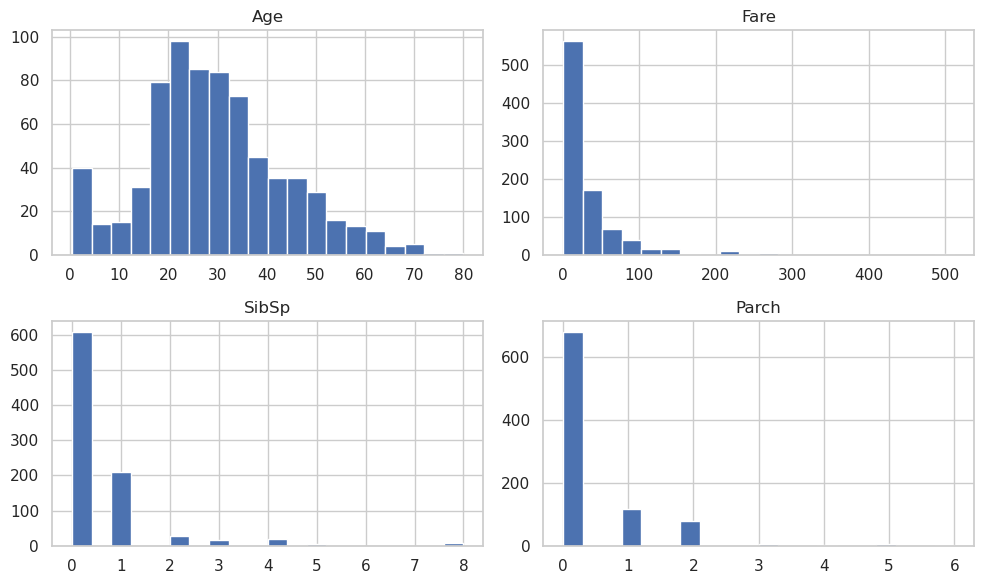

In [38]:
# 2. Univariate Analysis

numeric_cols = ["Age", "Fare", "SibSp", "Parch"]

# Histograms code is written for you
df[numeric_cols].hist(bins=20, figsize=(10, 6))
plt.tight_layout()
plt.show()

# Write Countplots code for key categorical variables [You need to complete]
cat_cols = ["Sex", "Pclass", "Embarked"]

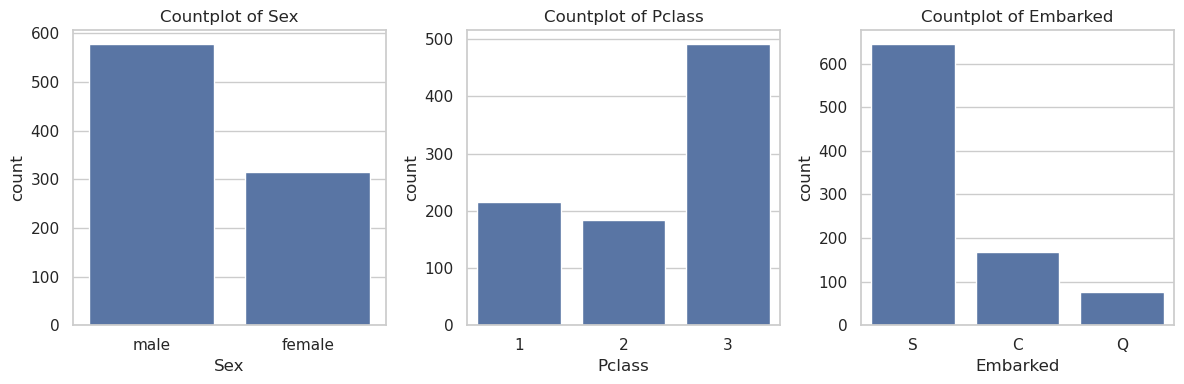

In [39]:
# Countplots for categorical variables
import seaborn as sns
import matplotlib.pyplot as plt

cat_cols = ["Sex", "Pclass", "Embarked"]

plt.figure(figsize=(12, 4))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(1, 3, i)
    sns.countplot(data=df, x=col)
    plt.title(f"Countplot of {col}")

plt.tight_layout()
plt.show()

#### Write Your insights
- Insight 1: 
The Age distribution is right-skewed, with most passengers between 20–40 years old. There are very few children and elderly passengers compared to adults.


- Insight 2: 
The Fare distribution is highly skewed, with many low-fare tickets and a small number of very expensive fares. This indicates strong economic class differences among passengers. 

- Insight 3:
Among categorical variables, the dataset shows more males than females, and most passengers traveled in 3rd class. The Embarked column shows that the majority of passengers boarded from port ‘S’ (Southampton).  

---
### 3. Bivariate Analysis with Target (15 marks)
Use `Survived` as the target variable.

**Tasks:**
- Compute and plot a **correlation heatmap** for numeric features, including `Survived`.
- Create a **pairplot** for: `Age`, `Fare`, `SibSp`, `Parch`, and `Survived`.
- Write **two to three insights**, including which variables seem associated with survival.


In [40]:
# 3. Bivariate Analysis with Target

num_for_corr = ["Survived", "Age", "Fare", "SibSp", "Parch"]
## Complete this code block to generate correlation heatmap and pairplot [You need to complete]

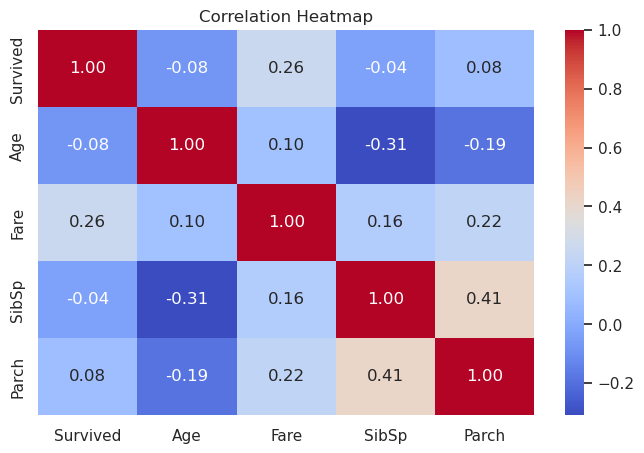

In [41]:
plt.figure(figsize=(8, 5))
corr = df[num_for_corr].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

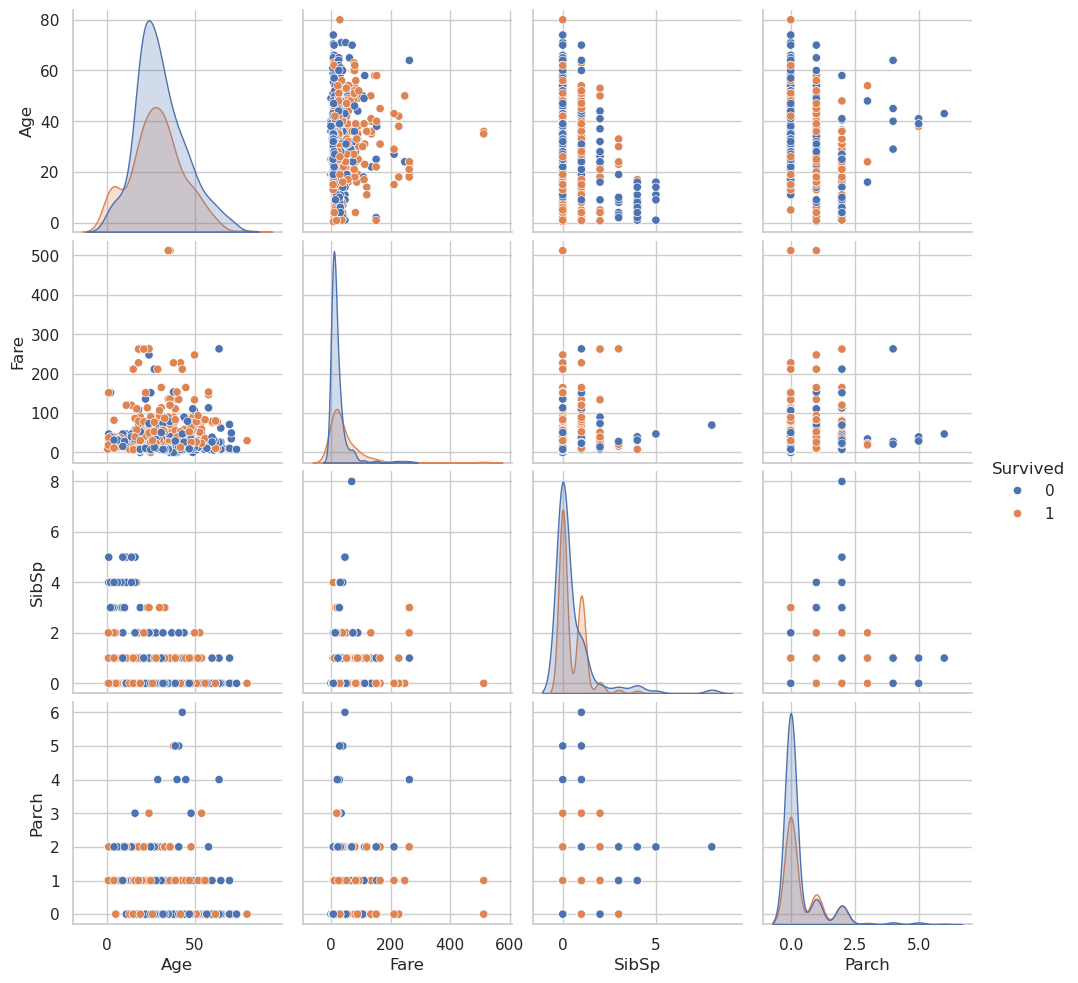

In [42]:
sns.pairplot(df[num_for_corr], hue="Survived")
plt.show()

#### Your insights
- Insight 1:
The correlation heatmap shows that Fare has a positive correlation with Survived, meaning passengers who paid higher fares (typically higher class) had a better chance of survival.

- Insight 2:  
SibSp and Parch show weak correlations with survival, suggesting that family size alone is not a strong predictor of whether a passenger survived.

- Insight 3:  
From the pairplot, survivors appear more concentrated among passengers with higher fares and younger ages. This indicates that wealthier passengers and children may have had better survival rates.

---
### 4. Categorical vs Target Analysis (5 marks)
**Tasks:**
For each of the following categorical features: `Sex`, `Pclass`, `Embarked`:
- Plot a **bar chart** showing the proportion of passengers who survived in each category.
- Write **two short insights** about which categories have higher or lower survival chances.



Survival proportion by Sex:


Survived,0,1
Sex,,
female,0.257962,0.742038
male,0.811092,0.188908


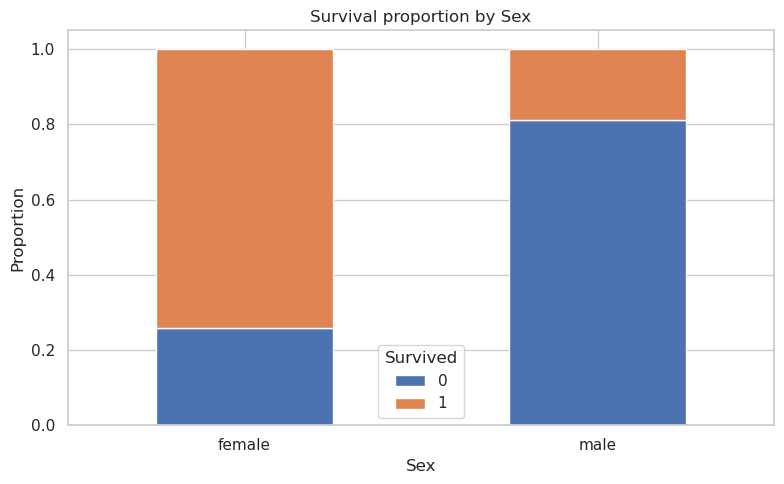


Survival proportion by Pclass:


Survived,0,1
Pclass,,
1,0.370370,0.629630
2,0.527174,0.472826
3,0.757637,0.242363


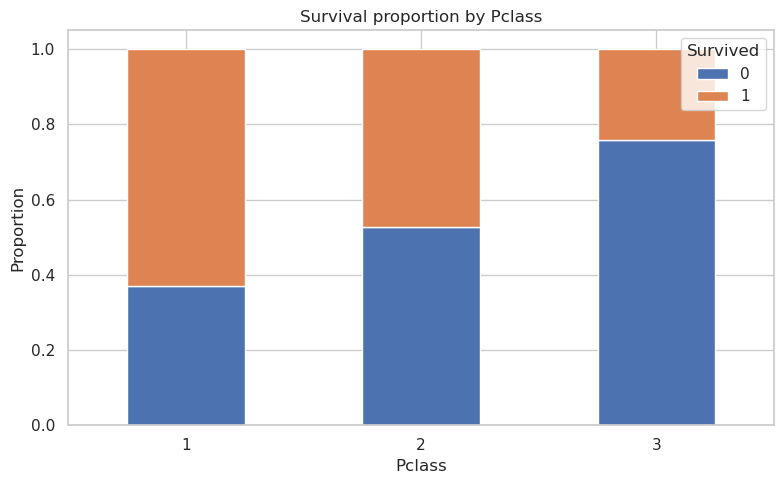


Survival proportion by Embarked:


Survived,0,1
Embarked,,
C,0.446429,0.553571
Q,0.610390,0.389610
S,0.663043,0.336957


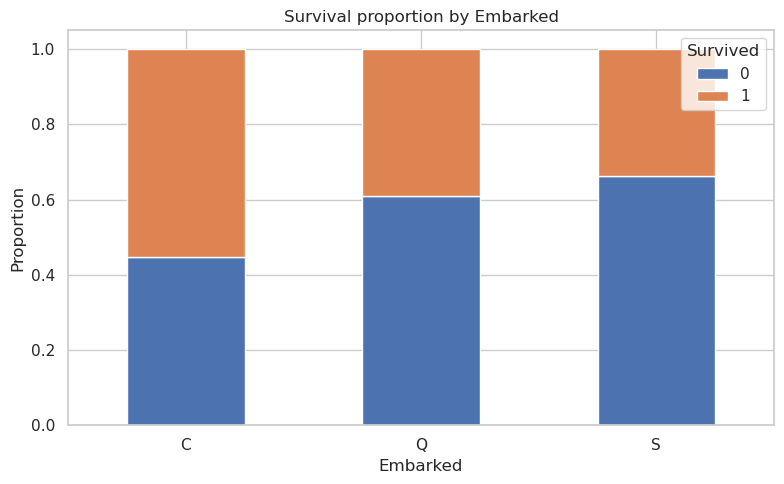

In [43]:
# 4. Categorical vs Target Analysis [Bar chart code is written for you]

cat_target_cols = ["Sex", "Pclass", "Embarked"]

for c in cat_target_cols:
    ct = pd.crosstab(df[c], df["Survived"], normalize="index")
    print(f"\nSurvival proportion by {c}:")
    display(ct)
    ct.plot(kind="bar", stacked=True)
    plt.title(f"Survival proportion by {c}")
    plt.ylabel("Proportion")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

#### Your insights
- Insight 1:  
- Insight 2:  

Sex

- Insight 1: Females have a much higher survival proportion compared to males — survival is strongly gender-dependent.

- Insight 2: Males show a very low survival rate, indicating they were far less likely to survive than females.

Pclass

- Insight 1: Passengers in 1st class have the highest survival proportion among all classes.

- Insight 2: 3rd-class passengers have the lowest survival rate, showing a clear decline in survival chance as class decreases.

Embarked

- Insight 1: Passengers who embarked from Cherbourg (C) show the highest survival proportion.

- Insight 2: Those who embarked from Southampton (S) have the lowest survival proportion among the three ports.

---
## Part B: Basic Data Preprocessing – 45 marks

Focus: **Handling missing values, encoding categorical variables, and scaling numeric features.**

### 5. Handling Missing Values (15 marks)
**Tasks:**
1. Show the count of missing values in each column.
2. Decide how to handle missing values for:
   - `Age` (numeric)
   - `Embarked` (categorical)
   - `Cabin` (many missing values)
3. Implement your chosen strategy in code.
4. Show missing value counts again to confirm.
5. Explain your choices in **3–4 sentences**.


In [44]:
# 5. Handling Missing Values

print("Missing values before:") #[Task 1 is done for you]
print(df.isna().sum())

# Drop Cabin (Complete this code block)
df = df.drop(columns=["Cabin"])

# Fill Age (Complete this code block)
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill Embarked (Complete this code block)
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

print("\nMissing values after handling:")
print(df.isna().sum())

Missing values before:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values after handling:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


#### Explanation of your strategy
- Why you dropped or kept `Cabin`:  
- Why you used median/mean for `Age`:  
- Why you used mode or another method for `Embarked`:  

I dropped the Cabin column because it contains a very large proportion of missing values, making it unreliable and not useful for modeling.

For Age, I used the median because it is a numeric column with outliers, and the median is more robust than the mean.

For Embarked, I used the mode since it is a categorical variable and filling with the most frequent category preserves the distribution.

After applying these strategies, the dataset contains no remaining missing values in the key features.

---
### 6. Encoding Categorical Variables (15 marks)
Focus on the following categorical features:
- `Sex`
- `Embarked`
- `Pclass` (treat as categorical)

**Tasks:**
- Use `OneHotEncoder` from sklearn to encode these features.
- Keep `Survived` and the main numeric features (`Age`, `Fare`, `SibSp`, `Parch`).
- Show the shape and head of the encoded DataFrame.


In [ ]:
# 6. Encoding Categorical Variables


df_enc = df.copy()

# Select features for encoding and keep important numeric ones
cat_features = ["Sex", "Embarked", "Pclass"]
numeric_features = ["Age", "Fare", "SibSp", "Parch"]
target_col = "Survived"

# One hot encode categorical variables [You need to do]
ohe = OneHotEncoder(sparse_output=False, drop="first")  
encoded_array = ohe.fit_transform(df_enc[cat_features])


encoded_df = pd.DataFrame(
    encoded_array,
    columns=ohe.get_feature_names_out(cat_features),
    index=df_enc.index
)


# Build final encoded DataFrame
df_model = pd.concat([
    df_enc[[target_col] + numeric_features],
    encoded_df
], axis=1)

print("Shape after encoding:", df_model.shape)
display(df_model.head())

Shape after encoding: (891, 10)


,Survived,Age,Fare,SibSp,Parch,Sex_male,Embarked_Q,Embarked_S,Pclass_2,Pclass_3
0,0,22.0,7.2500,1,0,1.0,0.0,1.0,0.0,1.0
1,1,38.0,71.2833,1,0,0.0,0.0,0.0,0.0,0.0
2,1,26.0,7.9250,0,0,0.0,0.0,1.0,0.0,1.0
3,1,35.0,53.1000,1,0,0.0,0.0,1.0,0.0,0.0
4,0,35.0,8.0500,0,0,1.0,0.0,1.0,0.0,1.0


---
### 7. Scaling Numeric Features (15 marks)
**Tasks:**
- Use `StandardScaler` on the numeric features: `Age`, `Fare`, `SibSp`, `Parch`.
- Plot boxplots of these features **before** and **after** scaling.
- Write **two sentences** explaining how scaling changes the numeric values and why it is useful before training some ML models.


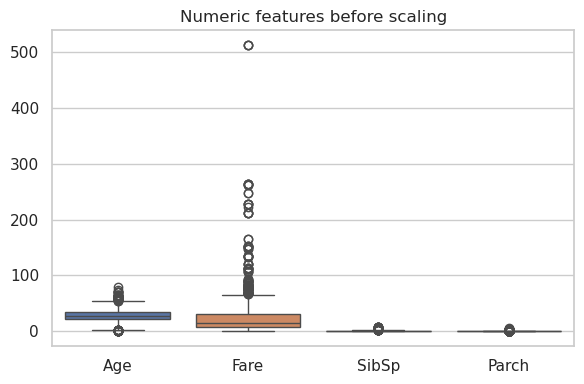

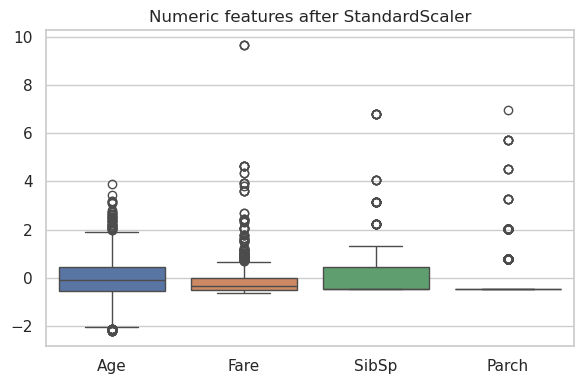

In [50]:
# 7. Scaling Numeric Features

score_cols = ["Age", "Fare", "SibSp", "Parch"]

# Boxplot before scaling
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_model[score_cols])
plt.title("Numeric features before scaling")
plt.tight_layout()
plt.show()

# Apply StandardScaler [You need to do]
scaler = StandardScaler()
df_scaled = df_model.copy()
df_scaled[score_cols] = scaler.fit_transform(df_model[score_cols])

# Boxplot after scaling
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_scaled[score_cols])
plt.title("Numeric features after StandardScaler")
plt.tight_layout()
plt.show()

#### Your observations on scaling
- Sentence 1: 
After scaling, all numeric features are transformed to have mean 0 and standard deviation 1, so their values are centered around zero.

- Sentence 2:  
Scaling is useful because it ensures all features contribute equally during model training, especially for distance-based methods like KNN or gradient-based models like logistic regression.

---
### 8. Simple Feature Quality Check (5 marks)
**Tasks:**
- Show `.info()` of the final processed DataFrame (`df_scaled`).
- Confirm there are no missing values.
- Confirm that all remaining features are numeric and suitable for most ML models.
- Write **one short concluding remark** about dataset readiness.


In [51]:
# 8. Simple Feature Quality Check
print(df_scaled.info())

print("\nTotal missing values in final DataFrame:", df_scaled.isna().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Age         891 non-null    float64
 2   Fare        891 non-null    float64
 3   SibSp       891 non-null    float64
 4   Parch       891 non-null    float64
 5   Sex_male    891 non-null    float64
 6   Embarked_Q  891 non-null    float64
 7   Embarked_S  891 non-null    float64
 8   Pclass_2    891 non-null    float64
 9   Pclass_3    891 non-null    float64
dtypes: float64(9), int64(1)
memory usage: 69.7 KB
None

Total missing values in final DataFrame: 0


## Concluding Remark

The final processed dataset is fully numeric, contains no missing values, and is now clean and ready to be used directly for training machine learning models.

#### Final remark on dataset readiness
- Your remark:  

---
## Submission
- Run all cells from top to bottom to make sure everything works.
- Set the Colab file's shareable link to ‘Anyone with the link’ and ‘View’ access, then submit it in the Phitron Assignment module's Assignment submission section.